In [1]:
!pip install transformers torch pandas scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 83.4 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.8.93
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.9.90
    Uninstalling nvidia-curand-cu12-1

In [2]:
!pip install "transformers[torch]"

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments

2025-04-17 16:02:09.936711: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744905730.132747      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744905730.187411      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
df = pd.read_csv('/kaggle/input/hcai-dataset/scam_dataset_india.csv', on_bad_lines='skip')

In [3]:
df.head()

,labels,text
0,fraud,"hello, i m bank manager of SBI, ur debit card ..."
1,fraud,Todays Vodafone numbers ending with 4882 are s...
2,normal,Please don't say like that. Hi hi hi
3,normal,Thank you!
4,normal,Oh that was a forwarded message. I thought you...


In [4]:
df.shape

(5925, 2)

In [5]:
df.rename(columns={'labels':'label','text':'text'},inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5925 entries, 0 to 5924
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5925 non-null   object
 1   text    5925 non-null   object
dtypes: object(2)
memory usage: 92.7+ KB


In [7]:
df.describe()

,label,text
count,5925,5925
unique,2,5601
top,normal,"Sorry, I'll call later"
freq,5287,25


**Data Cleaning**

In [8]:
df

,label,text
0,fraud,"hello, i m bank manager of SBI, ur debit card ..."
1,fraud,Todays Vodafone numbers ending with 4882 are s...
2,normal,Please don't say like that. Hi hi hi
3,normal,Thank you!
4,normal,Oh that was a forwarded message. I thought you...
...,...,...
5920,fraud,to get 1000 INR voucher please call on 8898655...
5921,fraud,to get free access of google cloud account hit...
5922,fraud,to get free AWS cloud account hit on given mes...
5923,fraud,to get free access of Microsoft Azure hit on g...


In [9]:
def spam_to_1(text):
    if(text=='fraud'):
        return 1
    return 0

In [10]:
df['label']=df['label'].apply(spam_to_1)

In [11]:
df

,label,text
0,1,"hello, i m bank manager of SBI, ur debit card ..."
1,1,Todays Vodafone numbers ending with 4882 are s...
2,0,Please don't say like that. Hi hi hi
3,0,Thank you!
4,0,Oh that was a forwarded message. I thought you...
...,...,...
5920,1,to get 1000 INR voucher please call on 8898655...
5921,1,to get free access of google cloud account hit...
5922,1,to get free AWS cloud account hit on given mes...
5923,1,to get free access of Microsoft Azure hit on g...


In [12]:
df.label.value_counts()

label
0    5287
1     638
Name: count, dtype: int64

In [13]:
df.duplicated().sum()

323

In [14]:
df.drop_duplicates().shape

(5602, 2)

In [15]:
df.duplicated().sum(),df.drop_duplicates().shape[0],df.shape[0]

(323, 5602, 5925)

In [16]:
df=df.drop_duplicates()

In [17]:
df.shape

(5602, 2)

**EDA**

In [18]:
df.label.value_counts()

label
0    5013
1     589
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x79ea4ae49f50>,
 [Text(-1.0405359113437795, 0.3567702582951253, 'ham'),
  Text(1.0405358862913452, -0.35677033136162656, 'spam')],
 [Text(-0.5675650425511524, 0.19460195907006836, '89.49'),
  Text(0.5675650288861882, -0.19460199892452354, '10.51')])

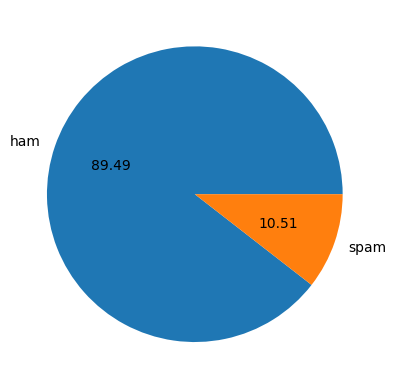

In [19]:
import matplotlib.pyplot as plt 

plt.pie(df['label'].value_counts(),labels=['ham','spam'],autopct="%0.2f")

In [20]:
# Split dataset
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'].tolist(),
    df['label'].tolist(),  
    test_size=0.2, 
    random_state=42
)

In [21]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [22]:
# Tokenize inputs
train_encodings = tokenizer(
    train_texts, 
    truncation=True, 
    padding='max_length', 
    max_length=256
)

In [23]:
val_encodings = tokenizer(
    val_texts, 
    truncation=True, 
    padding='max_length', 
    max_length=256
)

In [24]:
# Create torch dataset
class CallDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = CallDataset(train_encodings, train_labels)
val_dataset = CallDataset(val_encodings, val_labels)

In [25]:
# Initialize model
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2,
    attention_probs_dropout_prob=0.2,  # Increased dropout
    hidden_dropout_prob=0.2
)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [26]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model.to(device)

Using device: cuda


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.2, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [27]:
# training_args = TrainingArguments(
#     output_dir='./results',
#     run_name='hcai-1',
#     num_train_epochs=3,
#     per_device_train_batch_size=16,
#     per_device_eval_batch_size=16,
#     warmup_steps=500,
#     weight_decay=0.01,
#     logging_dir='./logs',
#     logging_steps=10,
#     eval_strategy='epoch',
#     save_strategy='epoch',
#     load_best_model_at_end=True,
#     report_to="none"  
# )

training_args = TrainingArguments(
    output_dir='./results',
    run_name='hcai-v2',
    num_train_epochs=4,  # Increased from 3
    per_device_train_batch_size=32,  # Larger batch size
    per_device_eval_batch_size=32,
    learning_rate=2e-5,  # Explicitly set learning rate
    warmup_ratio=0.1,  # 10% of total steps for warmup
    weight_decay=0.05,  # Increased regularization
    logging_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',  # Focus on F1 for imbalanced data
    report_to="none",
    fp16=True  # Enable mixed-precision training if using a GPU
)

In [28]:
# Compute metrics function
def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {
        'accuracy': accuracy_score(p.label_ids, preds),
        'f1': f1_score(p.label_ids, preds)
    }

In [29]:
# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# Train the model
trainer.train()

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.347600,0.057959,0.985727,0.933884
2,0.056200,0.036849,0.991079,0.960630
3,0.038900,0.045576,0.991971,0.964706
4,0.035100,0.053388,0.991971,0.964427


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


TrainOutput(global_step=284, training_loss=0.09918323243168038, metrics={'train_runtime': 450.3133, 'train_samples_per_second': 39.803, 'train_steps_per_second': 0.631, 'total_flos': 2358001278136320.0, 'train_loss': 0.09918323243168038, 'epoch': 4.0})

In [30]:
# Evaluate on validation set
results = trainer.evaluate()
print(results)

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


{'eval_loss': 0.04557565599679947, 'eval_accuracy': 0.991971454058876, 'eval_f1': 0.9647058823529412, 'eval_runtime': 9.4826, 'eval_samples_per_second': 118.216, 'eval_steps_per_second': 1.898, 'epoch': 4.0}


In [31]:
# Save model
model.save_pretrained('./fraud_detection_bert')
tokenizer.save_pretrained('./fraud_detection_bert')

('./fraud_detection_bert/tokenizer_config.json',
 './fraud_detection_bert/special_tokens_map.json',
 './fraud_detection_bert/vocab.txt',
 './fraud_detection_bert/added_tokens.json')

In [32]:
# Inference example
def predict(text):
    inputs = tokenizer(
        text, 
        return_tensors='pt', 
        truncation=True, 
        padding=True, 
        max_length=128
    ).to(device)
    
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():  # Disable gradient tracking
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        predicted_class = torch.argmax(probs, dim=1).item()
    
    return probs.squeeze().cpu().numpy(), predicted_class

# Test prediction
test_text = "This is a test call to verify your account details please"
probs, predicted_class = predict(test_text)

print(f"Prediction probabilities: [Normal: {probs[0]:.6f}, Fraud: {probs[1]:.6f}]")
if predicted_class == 1:
    print("🚨 This is a fraud call")
else:
    print("✅ This is a normal call")


Prediction probabilities: [Normal: 0.015204, Fraud: 0.984796]
🚨 This is a fraud call


In [33]:
from tabulate import tabulate

# test_texts = [
#     # 🚨 Fraud with subtlety
#     "Your Zelle payment to John Smith (john-smith@mail.com) for $1,200 is pending. Reply STOP to cancel.",  # Fake transaction alert
#     "Mom, I changed my number. Text me here from now on.",  # Number change scam precursor
    
#     # ✅ Normal but urgent-sounding
#     "EMERGENCY: Your sister is in labor! Heading to Mercy Hospital now.",  # Real emergency
#     "URGENT: The client needs the proposal by 5 PM. Can you prioritize this?"  # Work urgency
# ]


test_texts = [
    # 🚨 Scam / Deepfake-style Messages
    "Hi Grandma, I’m in jail and I need money right away. Please don’t tell Mom.",
    "This is Officer Daniels from the IRS. You owe back taxes and must pay now or face arrest.",
    "Your bank account has been compromised. Please provide your card number to secure it.",
    "Congratulations! You’ve won a prize. Just send a small processing fee to claim it.",
    "Hello, this is your grandson. I need help. Send me $500 through a gift card immediately.",
    "Your computer has a virus. Call this number to fix it now.",
    "I need you to transfer money urgently. I can’t explain, just trust me.",
    "I’m stuck in Mexico and lost my passport. Can you wire $1000 to this Western Union account?",

    # ✅ Legitimate / Normal Messages
    "Hey Mom, just checking in. I’ll be home late from work tonight.",
    "This is your doctor’s office confirming your appointment for tomorrow at 3 PM.",
    "Don’t forget the groceries! We’re out of milk and eggs.",
    "Thanks for the birthday wishes! Hope to see you soon.",
    "I emailed you the presentation slides. Let me know if you need anything else.",
    "Can you pick up the kids from school today?",
    "Meeting went great. I'll send over the notes tonight.",
    "Happy holidays! Just wanted to say hi and send some love."
]

# 🔹 Predict on all test messages and display results
results = []
for i, text in enumerate(test_texts, 1):
    probs, predicted_class = predict(text)
    label = "Fraud" if predicted_class == 1 else "Normal"
    results.append([i, text[:70] + ("..." if len(text) > 70 else ""), label, f"{probs[0]:.4f}", f"{probs[1]:.4f}"])

print("\n📊 Prediction Results:")
print(tabulate(results, headers=["#", "Message (truncated)", "Prediction", "Normal Prob", "Fraud Prob"]))


📊 Prediction Results:
  #  Message (truncated)                                                        Prediction      Normal Prob    Fraud Prob
---  -------------------------------------------------------------------------  ------------  -------------  ------------
  1  Hi Grandma, I’m in jail and I need money right away. Please don’t tell...  Normal               0.9997        0.0003
  2  This is Officer Daniels from the IRS. You owe back taxes and must pay ...  Normal               0.9992        0.0008
  3  Your bank account has been compromised. Please provide your card numbe...  Fraud                0.001         0.999
  4  Congratulations! You’ve won a prize. Just send a small processing fee ...  Fraud                0.2992        0.7008
  5  Hello, this is your grandson. I need help. Send me $500 through a gift...  Fraud                0.0008        0.9992
  6  Your computer has a virus. Call this number to fix it now.                 Normal               0.9943        0.0057
  

In [34]:
import shutil
from IPython.display import FileLink

# Zip the folder
shutil.make_archive('fraud_detection_bert', 'zip', './fraud_detection_bert')

# Create a download link
FileLink('fraud_detection_bert.zip')

/kaggle/working/fraud_detection_bert.zip